# 🍽️ KitchenIQ — Prophet Model Training Guide
### Food Portion Prediction for UTP Cafeteria

---

This notebook trains a **Facebook Prophet** model on your synthetic UTP cafeteria sales data.

**What this notebook does — step by step:**
1. Install required libraries
2. Load and explore your data
3. Prepare data in Prophet format
4. Add UTP academic calendar as custom seasonality
5. Add weather and other regressors
6. Train the model
7. Evaluate model performance
8. Make predictions with explanations
9. Save the trained model

> ⚠️ **Run each cell one at a time** (Shift + Enter). Do not skip cells.

---
## STEP 1 — Install Libraries
Run this once. You can skip it next time if already installed.

In [1]:
# Install all required libraries
# This may take 2-3 minutes the first time
!pip install prophet pandas numpy scikit-learn matplotlib seaborn joblib groq python-dotenv


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## STEP 2 — Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric

from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from datetime import date

print('✅ All libraries loaded successfully!')
print(f'pandas  : {pd.__version__}')
print(f'numpy   : {np.__version__}')

Importing plotly failed. Interactive plots will not work.


✅ All libraries loaded successfully!
pandas  : 3.0.1
numpy   : 2.4.3


---
## STEP 3 — Load Your Data

> 📁 Make sure your CSV file is in the **same folder** as this notebook.
> Update the filename below if needed.

In [3]:
# ── Load dataset ──────────────────────────────────────────────────────────────
# Change this path to wherever you saved the CSV
DATA_PATH = 'kitcheniq_sales_full.csv'

df = pd.read_csv(DATA_PATH, parse_dates=['date'])

print(f'✅ Data loaded!')
print(f'   Rows         : {len(df):,}')
print(f'   Date range   : {df.date.min().date()} → {df.date.max().date()}')
print(f'   Menu items   : {df.menu_item.nunique()}')
print(f'   Columns      : {list(df.columns)}')
print()
df.head()

✅ Data loaded!
   Rows         : 32,103
   Date range   : 2020-01-01 → 2024-12-31
   Menu items   : 17
   Columns      : ['date', 'day_of_week', 'week_number', 'month', 'year', 'menu_item', 'meal_type', 'food_category', 'expected_pax', 'actual_portions', 'weather', 'academic_status', 'is_public_holiday', 'is_long_weekend', 'is_wednesday_eve', 'is_exam_period', 'is_semester_break', 'is_ramadan', 'is_end_of_month', 'demand_multiplier', 'prediction_context', 'split']



,date,day_of_week,week_number,month,year,menu_item,meal_type,food_category,expected_pax,actual_portions,...,is_public_holiday,is_long_weekend,is_wednesday_eve,is_exam_period,is_semester_break,is_ramadan,is_end_of_month,demand_multiplier,prediction_context,split
0,2020-01-01,wednesday,1,1,2020,Nasi Lemak,breakfast,rice,158,4,...,1,0,0,0,0,0,0,0.0672,Base demand: 35 portions per 100 pax | Expecte...,train
1,2020-01-01,wednesday,1,1,2020,Roti Canai,breakfast,bread,158,3,...,1,0,0,0,0,0,0,0.0672,Base demand: 28 portions per 100 pax | Expecte...,train
2,2020-01-01,wednesday,1,1,2020,Mee Goreng Mamak,breakfast,noodles,158,2,...,1,0,0,0,0,0,0,0.0672,Base demand: 20 portions per 100 pax | Expecte...,train
3,2020-01-01,wednesday,1,1,2020,Toast & Eggs,breakfast,western,158,2,...,1,0,0,0,0,0,0,0.0672,Base demand: 15 portions per 100 pax | Expecte...,train
4,2020-01-01,wednesday,1,1,2020,Kuih Assorted,breakfast,snack,158,1,...,1,0,0,0,0,0,0,0.0672,Base demand: 12 portions per 100 pax | Expecte...,train


In [ ]:
#NO NEED
# ── Setting MCO period ─────────────────────────────────
# During MCO (18 Mar – 14 Apr 2020), campus was fully closed
# Students were home, cafeteria was essentially shut

mco_start = pd.Timestamp('2020-03-18')
mco_end   = pd.Timestamp('2020-04-14')

mco_mask = (df['date'] >= mco_start) & (df['date'] <= mco_end)

print(f"MCO rows found: {mco_mask.sum()}")
print(f"Avg portions BEFORE fix: {df[mco_mask]['actual_portions'].mean():.1f}")

# Set to 0–2 portions (reflects skeleton staff / no students)
import numpy as np
df.loc[mco_mask, 'actual_portions'] = np.random.randint(0, 3, size=mco_mask.sum())
df.loc[mco_mask, 'academic_status'] = 'mco_closure'

print(f"Avg portions AFTER fix : {df[mco_mask]['actual_portions'].mean():.1f}")
df.to_csv('kitcheniq_sales_train_withmco.csv', index=False)

In [6]:
# ── Add missing columns & save fixed dataset ──────────────────────────────────

# 1. Add is_mco column if missing
if 'is_mco' not in df.columns:
    mco_start = pd.Timestamp('2020-03-18')
    mco_end   = pd.Timestamp('2020-04-14')
    df['is_mco'] = ((df['date'] >= mco_start) & (df['date'] <= mco_end)).astype(int)
    print(f"✅ is_mco added — {df['is_mco'].sum()} MCO rows flagged")
else:
    print(f"✅ is_mco already exists — {df['is_mco'].sum()} MCO rows")

# 2. Fix MCO portions to near-zero while we're at it
import numpy as np
mco_mask = df['is_mco'] == 1
df.loc[mco_mask, 'actual_portions'] = np.random.randint(0, 3, size=mco_mask.sum())
print(f"✅ MCO portions corrected to near-zero")

# 3. Add is_study_week if missing
if 'is_study_week' not in df.columns:
    df['is_study_week'] = (df['academic_status'] == 'study_week').astype(int)
    print(f"✅ is_study_week added")

# 4. Add is_blended_learning if missing
if 'is_blended_learning' not in df.columns:
    df['is_blended_learning'] = (df['academic_status'] == 'blended_learning').astype(int)
    print(f"✅ is_blended_learning added")


✅ is_mco already exists — 492 MCO rows
✅ MCO portions corrected to near-zero


---
## STEP 4 — Explore the Data
Always look at your data before training. This helps catch problems early.

In [10]:
# ── Basic stats ───────────────────────────────────────────────────────────────
print('=== PORTIONS STATISTICS ===')
print(df['actual_portions'].describe().round(1))

print('\n=== ACADEMIC STATUS DISTRIBUTION ===')
print(df[df.meal_type=='lunch'].groupby('academic_status')['actual_portions']
        .agg(['count','mean']).round(1))

print('\n=== WEATHER DISTRIBUTION (lunch days only) ===')
print(df[df.meal_type=='lunch'].groupby('weather')['actual_portions']
        .agg(['count','mean']).round(1))

=== PORTIONS STATISTICS ===
count    32103.0
mean        31.2
std         26.5
min          0.0
25%         11.0
50%         24.0
75%         44.0
max        165.0
Name: actual_portions, dtype: float64

=== ACADEMIC STATUS DISTRIBUTION ===
                 count  mean
academic_status             
exam_period       1131  36.7
semester_active   8243  54.0
semester_break    2092  11.0
short_semester    1062  29.3

=== WEATHER DISTRIBUTION (lunch days only) ===
         count  mean
weather             
cloudy    3196  45.8
rainy     4127  31.0
sunny     5205  51.2


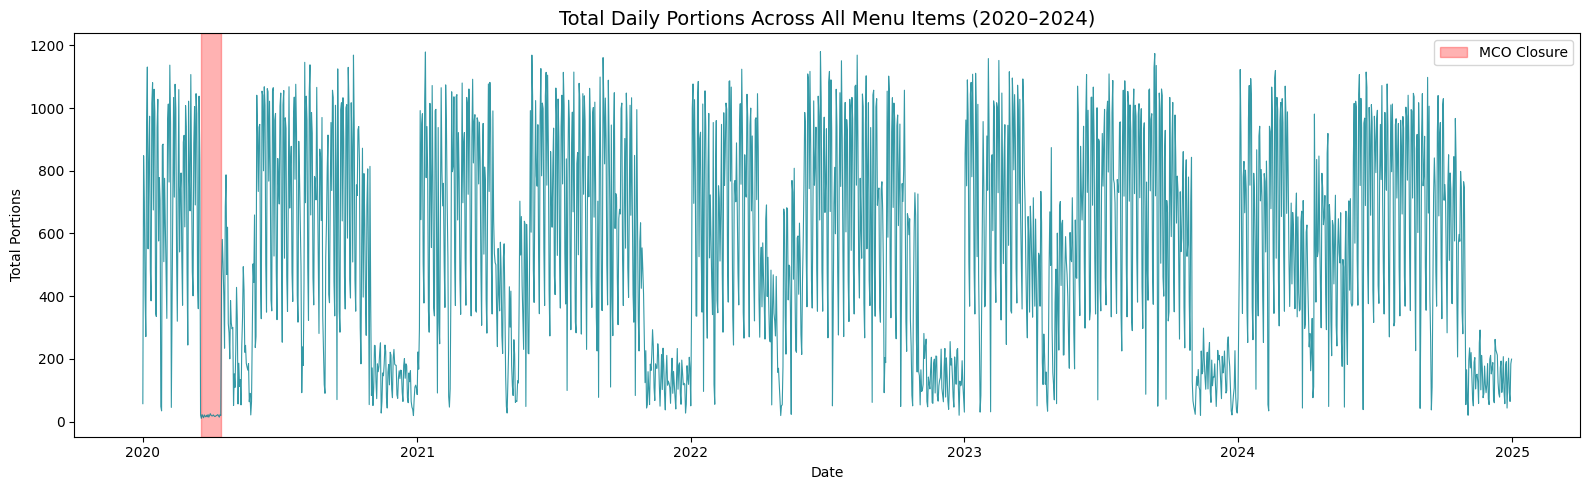


💡 You can clearly see semester patterns, breaks, and the MCO dip in 2020


In [11]:
# ── Plot total daily portions over time ───────────────────────────────────────
daily_total = df.groupby('date')['actual_portions'].sum().reset_index()

plt.figure(figsize=(16, 5))
plt.plot(daily_total['date'], daily_total['actual_portions'], 
         linewidth=0.8, color='#028090', alpha=0.8)
plt.title('Total Daily Portions Across All Menu Items (2020–2024)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Total Portions')
plt.axvspan(pd.Timestamp('2020-03-18'), pd.Timestamp('2020-04-14'), 
            alpha=0.3, color='red', label='MCO Closure')
plt.legend()
plt.tight_layout()
plt.show()
print('\n💡 You can clearly see semester patterns, breaks, and the MCO dip in 2020')

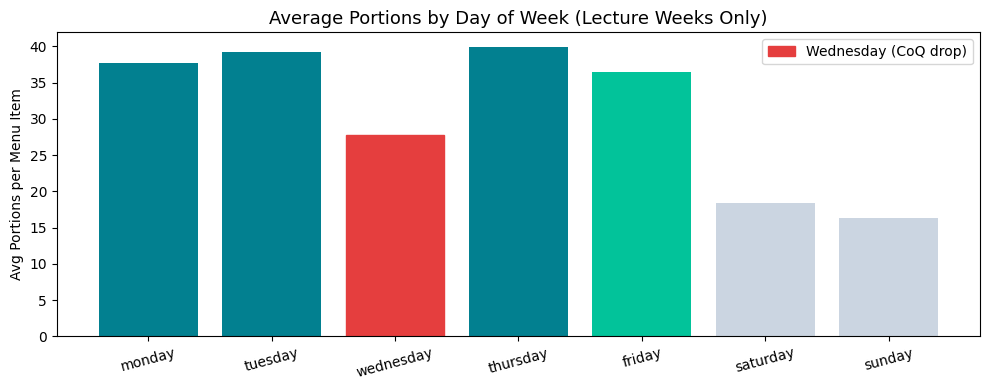

In [12]:
# ── Plot portions by day of week ──────────────────────────────────────────────
dow_order = ['monday','tuesday','wednesday','thursday','friday','saturday','sunday']
dow_avg = (df
             .groupby('day_of_week')['actual_portions']
             .mean()
             .reindex(dow_order))

plt.figure(figsize=(10, 4))
bars = plt.bar(dow_order, dow_avg, color=['#028090']*4 + ['#02C39A'] + ['#CBD5E1']*2)
plt.title('Average Portions by Day of Week (Lecture Weeks Only)', fontsize=13)
plt.ylabel('Avg Portions per Menu Item')
plt.xticks(rotation=15)
# Highlight Wednesday
bars[2].set_color('#E53E3E')
bars[2].set_label('Wednesday (CoQ drop)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#NOT USEFUL ANYMORE
# ── Plot portions by day of week latest ──────────────────────────────────────────────

# Debug check first
print("Unique academic_status values:", df['academic_status'].unique())
print("Total rows with 'lecture':", len(df[df['academic_status'] == 'lecture']))
print("Sample actual_portions:", df['actual_portions'].head())

# Filter lecture weeks only
lecture_df = df[df['academic_status'] == 'lecture'].copy()

# If empty, fall back to all data
if len(lecture_df) == 0:
    print("⚠️ No 'lecture' rows found — plotting all data instead")
    lecture_df = df.copy()

dow_order = ['monday','tuesday','wednesday','thursday','friday','saturday','sunday']

# Calculate average per day
dow_avg = (lecture_df
           .groupby('day_of_week')['actual_portions']
           .mean()
           .reindex(dow_order)
           .fillna(0))

print("\nAverage portions by day:\n", dow_avg.round(1))

# Plot
plt.figure(figsize=(10, 4))
colors = ['#028090','#028090','#E53E3E','#028090','#02C39A','#CBD5E1','#CBD5E1']
bars = plt.bar(dow_order, dow_avg, color=colors)
bars[2].set_label('Wednesday (CCA drop)')

plt.title('Average Portions by Day of Week (Lecture Weeks Only)', fontsize=13)
plt.ylabel('Avg Portions per Menu Item')
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()
plt.show()

---
## STEP 5 — Choose a Menu Item to Train

Prophet trains **one model per menu item + meal type** combination.
We will train them all and save each one.

First, let's do a **single example** so you understand the process, then we'll loop through all items.

In [13]:
# ── See all menu item + meal type combinations ────────────────────────────────
combos = df[['menu_item','meal_type']].drop_duplicates().sort_values(['meal_type','menu_item'])
combos = combos.reset_index(drop=True)
print('All trainable combinations:')
for i, row in combos.iterrows():
    print(f'  [{i:2d}]  {row.meal_type:12s}  {row.menu_item}')

All trainable combinations:
  [ 0]  breakfast     Kuih Assorted
  [ 1]  breakfast     Mee Goreng Mamak
  [ 2]  breakfast     Nasi Lemak
  [ 3]  breakfast     Roti Canai
  [ 4]  breakfast     Toast & Eggs
  [ 5]  dinner        Char Kuey Teow
  [ 6]  dinner        Nasi Campur
  [ 7]  dinner        Nasi Goreng Kampung
  [ 8]  dinner        Roti Canai Dinner
  [ 9]  dinner        Soup Noodles
  [10]  dinner        Western Set
  [11]  lunch         Burger / Sandwich
  [12]  lunch         Economy Rice
  [13]  lunch         Fried Rice
  [14]  lunch         Laksa
  [15]  lunch         Mee Goreng
  [16]  lunch         Nasi Ayam
  [17]  lunch         Nasi Campur


---
## STEP 6 — Define UTP Holidays for Prophet

Prophet accepts a special `holidays` DataFrame to understand special days.
We will include **public holidays + semester breaks + exam weeks**.

In [14]:
# ── Build Prophet holidays DataFrame ─────────────────────────────────────────
# Prophet needs columns: 'ds' (date), 'holiday' (name)
# Optional: 'lower_window', 'upper_window' for surrounding day effects

holiday_rows = []

# 1. Semester breaks (multiple days — add each day individually)
sem_breaks = df[df.academic_status == 'sem_break']['date'].unique()
for d in sem_breaks:
    holiday_rows.append({'ds': d, 'holiday': 'semester_break'})

# 2. Exam weeks
exam_days = df[df.academic_status == 'exam']['date'].unique()
for d in exam_days:
    holiday_rows.append({'ds': d, 'holiday': 'exam_week'})

# 3. Study weeks
study_days = df[df.academic_status == 'study_week']['date'].unique()
for d in study_days:
    holiday_rows.append({'ds': d, 'holiday': 'study_week'})

# 4. Blended learning days
blend_days = df[df.academic_status == 'blended_learning']['date'].unique()
for d in blend_days:
    holiday_rows.append({'ds': d, 'holiday': 'blended_learning'})

# 5. Public holidays
pub_hols = df[df.is_public_holiday == 1]['date'].unique()
for d in pub_hols:
    holiday_rows.append({'ds': d, 'holiday': 'public_holiday'})

# 6. MCO closure
mco_days = df[df.is_mco == 1]['date'].unique()
for d in mco_days:
    holiday_rows.append({'ds': d, 'holiday': 'mco_closure'})

# 7. Ramadan
ramadan_days = df[df.is_ramadan == 1]['date'].unique()
for d in ramadan_days:
    holiday_rows.append({'ds': d, 'holiday': 'ramadan'})

# 8. Pre-Eid exodus (1 week before Eid)
eid_dates = [pd.Timestamp('2020-05-24'), pd.Timestamp('2021-05-13'),
             pd.Timestamp('2022-05-03'), pd.Timestamp('2023-04-22'),
             pd.Timestamp('2024-04-10')]
for eid in eid_dates:
    for days_before in range(1, 7):
        d = eid - pd.Timedelta(days=days_before)
        holiday_rows.append({'ds': d, 'holiday': 'pre_eid_exodus'})

holidays_df = pd.DataFrame(holiday_rows)
holidays_df['ds'] = pd.to_datetime(holidays_df['ds'])
holidays_df = holidays_df.drop_duplicates(subset=['ds','holiday'])

print(f'✅ Holiday DataFrame built: {len(holidays_df)} entries')
print(holidays_df.groupby('holiday').size().sort_values(ascending=False))

✅ Holiday DataFrame built: 287 entries
holiday
ramadan           149
public_holiday     80
pre_eid_exodus     30
mco_closure        28
dtype: int64


---
## STEP 7 — Train a Single Model (Example: Nasi Lemak Breakfast)

We will go through this step by step so you understand what each part does.

In [15]:
# ── Filter data for one menu item ─────────────────────────────────────────────
TARGET_ITEM = 'Nasi Lemak'
TARGET_MEAL = 'breakfast'

item_df = df[
    (df.menu_item == TARGET_ITEM) & 
    (df.meal_type == TARGET_MEAL)
].copy()

# ── Prepare Prophet format ────────────────────────────────────────────────────
# Prophet requires EXACTLY these column names:
#   'ds' = date
#   'y'  = value to predict

item_df = item_df.rename(columns={
    'date':            'ds',
    'actual_portions': 'y'
})

# ── Encode weather as numbers (Prophet can't use text directly) ───────────────
weather_map = {'sunny': 0, 'cloudy': 1, 'rainy': 2}
item_df['weather_code'] = item_df['weather'].map(weather_map)

# ── Train / Test split ────────────────────────────────────────────────────────
train_df = item_df[item_df['split'] == 'train'].copy()
test_df  = item_df[item_df['split'] == 'test'].copy()

print(f'✅ Prepared data for: {TARGET_ITEM} ({TARGET_MEAL})')
print(f'   Training rows : {len(train_df)}')
print(f'   Testing rows  : {len(test_df)}')
print(f'   Training dates: {train_df.ds.min().date()} → {train_df.ds.max().date()}')
print(f'   Testing dates : {test_df.ds.min().date()}  → {test_df.ds.max().date()}')
train_df[['ds','y','weather','academic_status','is_public_holiday']].head()

✅ Prepared data for: Nasi Lemak (breakfast)
   Training rows : 1096
   Testing rows  : 731
   Training dates: 2020-01-01 → 2022-12-31
   Testing dates : 2023-01-01  → 2024-12-31


,ds,y,weather,academic_status,is_public_holiday
0,2020-01-01,4,rainy,semester_active,1
18,2020-01-02,43,rainy,semester_active,0
36,2020-01-03,37,rainy,semester_active,0
54,2020-01-04,19,rainy,semester_active,0
72,2020-01-05,17,rainy,semester_active,0


In [16]:
# ── Build and configure the Prophet model ─────────────────────────────────────

model = Prophet(
    # Use your UTP calendar holidays
    holidays=holidays_df,

    # Seasonality settings
    yearly_seasonality=True,    # Picks up semester patterns across years
    weekly_seasonality=True,    # Picks up Monday–Sunday patterns
    daily_seasonality=False,    # Not needed (we have one row per day)

    # How flexible the trend is
    # 'linear' = gradual growth/decline
    # 'flat'   = assume no long-term growth (good for cafeteria)
    growth='flat',

    # Uncertainty — lower = more confident, tighter predictions
    interval_width=0.90,

    # Seasonality mode:
    # 'additive'       = seasons add fixed amount (use when variance is constant)
    # 'multiplicative' = seasons multiply by % (use when variance grows with level)
    seasonality_mode='multiplicative',

    # How sensitive to change points (sudden pattern shifts like MCO)
    changepoint_prior_scale=0.05,

    # How sensitive to holiday effects
    holidays_prior_scale=10.0,
)

# ── Add extra regressors (external variables that affect demand) ───────────────
# These are columns in your data that Prophet should use as extra inputs

model.add_regressor('weather_code',      prior_scale=0.5, standardize=True)
model.add_regressor('is_long_weekend',   prior_scale=0.5, standardize=True)
model.add_regressor('is_wednesday_eve',  prior_scale=0.5, standardize=True)
model.add_regressor('is_end_of_month',   prior_scale=0.3, standardize=True)
model.add_regressor('expected_pax',      prior_scale=0.5, standardize=True)

# ── Add custom UTP academic seasonality ───────────────────────────────────────
# This tells Prophet about within-year academic cycles
# period=365.25/3 ≈ 4 months (3 semesters per year at UTP)
model.add_seasonality(
    name='utp_semester',
    period=121.75,    # ~4 months per semester cycle
    fourier_order=5,  # How complex the pattern can be (higher = more flexible)
    prior_scale=10.0
)

print('✅ Model configured!')
print('   Regressors added: weather, long weekend, wednesday, end-of-month, expected pax')
print('   Custom seasonality: UTP semester cycle')

✅ Model configured!
   Regressors added: weather, long weekend, wednesday, end-of-month, expected pax
   Custom seasonality: UTP semester cycle


In [17]:
# ── Train the model ───────────────────────────────────────────────────────────
# Select only the columns Prophet needs
regressor_cols = ['ds', 'y', 'weather_code', 'is_long_weekend', 
                  'is_wednesday_eve', 'is_end_of_month', 'expected_pax']

train_input = train_df[regressor_cols].copy()

print('Training model... (this may take 30–60 seconds)')
model.fit(train_input)
print('✅ Model trained successfully!')

Training model... (this may take 30–60 seconds)


15:09:51 - cmdstanpy - INFO - Chain [1] start processing
15:09:52 - cmdstanpy - INFO - Chain [1] done processing


✅ Model trained successfully!


---
## STEP 8 — Evaluate the Model

We test on data the model has **never seen** (2023–2024).

In [18]:
# ── Make predictions on test set ──────────────────────────────────────────────
test_input = test_df[['ds','weather_code','is_long_weekend',
                       'is_wednesday_eve','is_end_of_month','expected_pax']].copy()

forecast = model.predict(test_input)

# ── Merge predictions with actual values ──────────────────────────────────────
results = test_df[['ds','y']].merge(
    forecast[['ds','yhat','yhat_lower','yhat_upper']], 
    on='ds'
)

# Round predicted portions (you can't prepare 34.7 portions)
results['predicted_portions'] = results['yhat'].clip(lower=1).round().astype(int)
results['actual_portions']    = results['y'].astype(int)

# ── Calculate metrics ─────────────────────────────────────────────────────────
mae  = mean_absolute_error(results['actual_portions'], results['predicted_portions'])
mape = mean_absolute_percentage_error(results['actual_portions'], results['predicted_portions']) * 100

print('='*50)
print(f'  MODEL EVALUATION — {TARGET_ITEM} ({TARGET_MEAL})')
print('='*50)
print(f'  MAE  (Mean Absolute Error)  : {mae:.1f} portions')
print(f'  MAPE (Mean Absolute % Error): {mape:.1f}%')
print()
print('  HOW TO READ THESE:')
print(f'  MAE {mae:.1f} = on average, prediction is off by {mae:.1f} portions')
print(f'  MAPE {mape:.1f}% = on average, prediction is off by {mape:.1f}% of the actual value')
print()
if mape < 15:
    print('  ✅ GOOD — model is accurate enough for production use')
elif mape < 25:
    print('  ⚠️  ACCEPTABLE — model works but could be improved with more data')
else:
    print('  ❌ NEEDS IMPROVEMENT — consider adding more features or data')

results[['ds','actual_portions','predicted_portions']].head(10)

  MODEL EVALUATION — Nasi Lemak (breakfast)
  MAE  (Mean Absolute Error)  : 4.7 portions
  MAPE (Mean Absolute % Error): 30.1%

  HOW TO READ THESE:
  MAE 4.7 = on average, prediction is off by 4.7 portions
  MAPE 30.1% = on average, prediction is off by 30.1% of the actual value

  ❌ NEEDS IMPROVEMENT — consider adding more features or data


,ds,actual_portions,predicted_portions
0,2023-01-01,2,1
1,2023-01-02,45,31
2,2023-01-03,51,38
3,2023-01-04,45,40
4,2023-01-05,55,47
5,2023-01-06,44,40
6,2023-01-07,25,26
7,2023-01-08,23,29
8,2023-01-09,51,46
9,2023-01-10,62,52


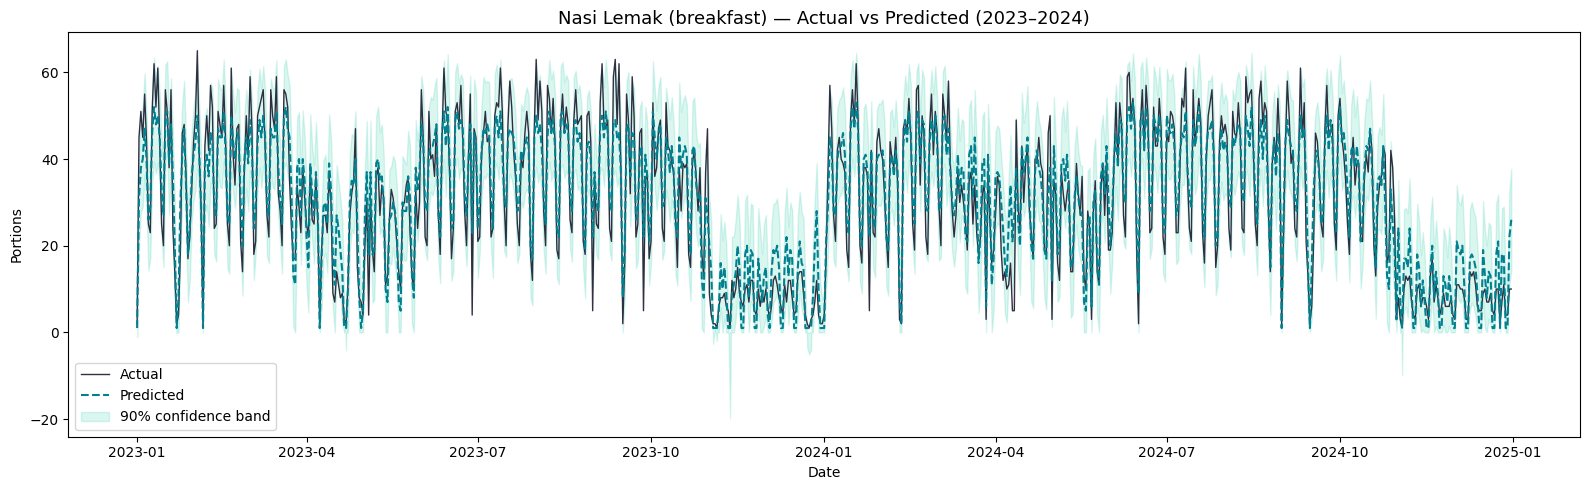

In [19]:
# ── Plot actual vs predicted ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(results['ds'], results['actual_portions'], 
        label='Actual', color='#1A1A2E', linewidth=1, alpha=0.9)
ax.plot(results['ds'], results['predicted_portions'], 
        label='Predicted', color='#028090', linewidth=1.5, linestyle='--')
ax.fill_between(results['ds'], 
                results['yhat_lower'].clip(lower=0), 
                results['yhat_upper'],
                alpha=0.15, color='#02C39A', label='90% confidence band')

ax.set_title(f'{TARGET_ITEM} ({TARGET_MEAL}) — Actual vs Predicted (2023–2024)', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Portions')
ax.legend()
plt.tight_layout()
plt.show()

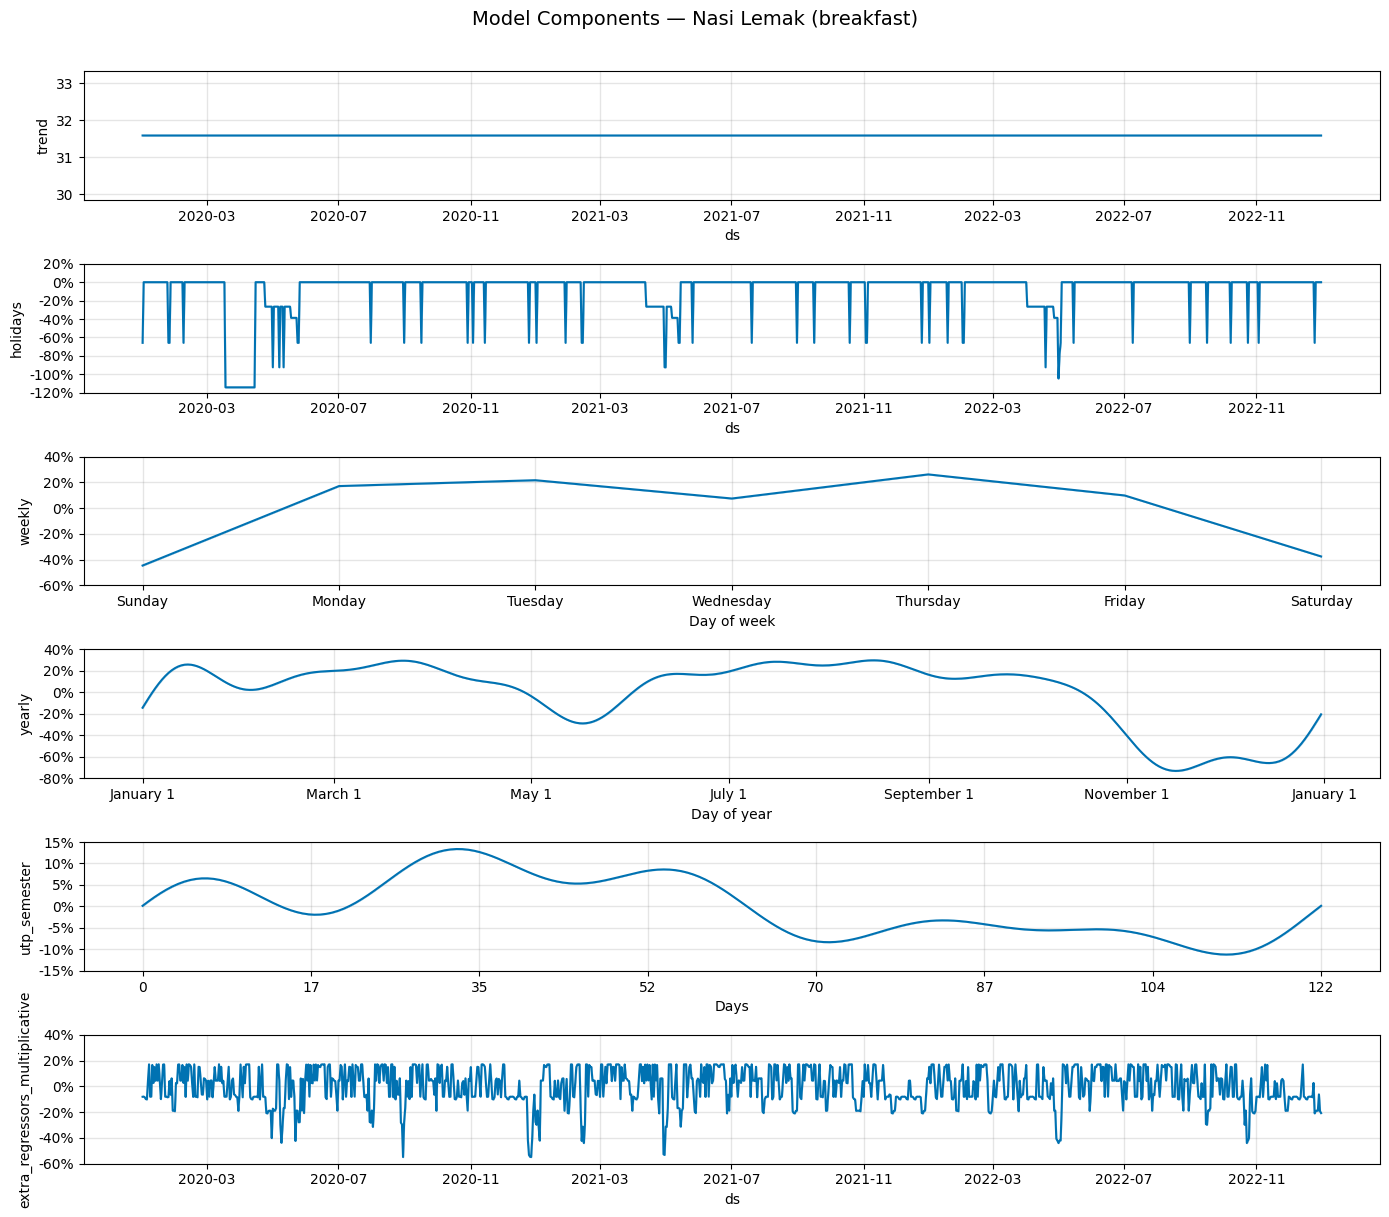


💡 These charts show:
   trend         = long-term direction
   weekly        = day-of-week pattern (Wednesday dip should be visible)
   yearly        = yearly academic cycle
   utp_semester  = 4-month semester rhythm
   holidays      = impact of public holidays, exam weeks, etc.


In [20]:
# ── Plot Prophet components (what drives the prediction) ──────────────────────
# This shows you HOW the model thinks — very useful for understanding

# Need to run predict on training data to get components
train_forecast = model.predict(train_input)

fig = model.plot_components(train_forecast)
fig.set_size_inches(14, 12)
plt.suptitle(f'Model Components — {TARGET_ITEM} ({TARGET_MEAL})', 
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
print('\n💡 These charts show:')
print('   trend         = long-term direction')
print('   weekly        = day-of-week pattern (Wednesday dip should be visible)')
print('   yearly        = yearly academic cycle')
print('   utp_semester  = 4-month semester rhythm')
print('   holidays      = impact of public holidays, exam weeks, etc.')

---
## STEP 9 — Make a Prediction with Context Explanation

This is the function your FastAPI will call. It returns the predicted portions **plus a human-readable explanation**.

In [21]:
# ── Prediction function with explanation ──────────────────────────────────────

def predict_with_context(model, input_date, weather, expected_pax,
                          is_long_weekend=0, is_wednesday_eve=0, 
                          is_end_of_month=0, menu_item='', meal_type=''):
    """
    Make a prediction and return both the number and the explanation.
    
    Parameters:
    -----------
    input_date      : str, format 'YYYY-MM-DD'
    weather         : str, 'sunny' / 'cloudy' / 'rainy'
    expected_pax    : int, how many students expected on campus
    is_long_weekend : 0 or 1
    is_wednesday_eve: 0 or 1 (only for dinner on Wednesday)
    is_end_of_month : 0 or 1
    """
    weather_map = {'sunny': 0, 'cloudy': 1, 'rainy': 2}
    
    future = pd.DataFrame({
        'ds':               [pd.Timestamp(input_date)],
        'weather_code':     [weather_map.get(weather, 0)],
        'expected_pax':     [expected_pax],
        'is_long_weekend':  [is_long_weekend],
        'is_wednesday_eve': [is_wednesday_eve],
        'is_end_of_month':  [is_end_of_month],
    })
    
    forecast = model.predict(future)
    predicted = max(1, round(float(forecast['yhat'].iloc[0])))
    lower     = max(1, round(float(forecast['yhat_lower'].iloc[0])))
    upper     = max(1, round(float(forecast['yhat_upper'].iloc[0])))
    
    # ── Build context explanation ──────────────────────────────────────────────
    context_parts = []
    
    if weather == 'rainy':
        context_parts.append('rainy weather reduces foot traffic')
    elif weather == 'cloudy':
        context_parts.append('cloudy weather (slight reduction)')

    if is_long_weekend:
        context_parts.append('long weekend — many students leave campus')

    if is_wednesday_eve:
        context_parts.append('Wednesday evening — co-curricular activities reduce dinner crowd')

    if is_end_of_month:
        context_parts.append('end of month — student budget fatigue')

    # Check if date falls in a known holiday period
    ts = pd.Timestamp(input_date)
    matching_holidays = holidays_df[holidays_df['ds'] == ts]['holiday'].tolist()
    for h in matching_holidays:
        if h == 'semester_break':    context_parts.append('semester break period')
        elif h == 'exam_week':       context_parts.append('exam week')
        elif h == 'study_week':      context_parts.append('study week')
        elif h == 'blended_learning':context_parts.append('blended learning week')
        elif h == 'public_holiday':  context_parts.append('public holiday')
        elif h == 'ramadan':         context_parts.append('Ramadan fasting month')
        elif h == 'pre_eid_exodus':  context_parts.append('pre-Eid student exodus')
        elif h == 'mco_closure':     context_parts.append('MCO campus closure')

    context = ('; '.join(context_parts) 
               if context_parts else 'normal operating day')

    return {
        'menu_item':          menu_item or 'Unknown',
        'meal_type':          meal_type or 'Unknown',
        'date':               input_date,
        'predicted_portions': predicted,
        'confidence_range':   f'{lower}–{upper}',
        'expected_pax':       expected_pax,
        'weather':            weather,
        'context':            context,
        'instruction':        f'Prepare exactly {predicted} portions of {menu_item or "this item"}.'
    }

print('✅ Prediction function ready!')

✅ Prediction function ready!


In [22]:
# ── TEST the prediction function ──────────────────────────────────────────────
# Try different scenarios:

# Scenario 1: Normal sunny Tuesday
result1 = predict_with_context(
    model, 
    input_date      = '2024-03-05',
    weather         = 'sunny',
    expected_pax    = 300,
    menu_item       = TARGET_ITEM,
    meal_type       = TARGET_MEAL
)
print('=== Scenario 1: Normal sunny Tuesday ===')
for k, v in result1.items():
    print(f'  {k:22s}: {v}')

print()

# Scenario 2: Rainy Wednesday
result2 = predict_with_context(
    model,
    input_date      = '2024-03-06',
    weather         = 'rainy',
    expected_pax    = 280,
    is_wednesday_eve= 0,   # breakfast not affected by CCA
    menu_item       = TARGET_ITEM,
    meal_type       = TARGET_MEAL
)
print('=== Scenario 2: Rainy Wednesday ===')
for k, v in result2.items():
    print(f'  {k:22s}: {v}')

=== Scenario 1: Normal sunny Tuesday ===
  menu_item             : Nasi Lemak
  meal_type             : breakfast
  date                  : 2024-03-05
  predicted_portions    : 51
  confidence_range      : 40–62
  expected_pax          : 300
  weather               : sunny
  context               : normal operating day
  instruction           : Prepare exactly 51 portions of Nasi Lemak.

=== Scenario 2: Rainy Wednesday ===
  menu_item             : Nasi Lemak
  meal_type             : breakfast
  date                  : 2024-03-06
  predicted_portions    : 38
  confidence_range      : 26–50
  expected_pax          : 280
  weather               : rainy
  context               : rainy weather reduces foot traffic
  instruction           : Prepare exactly 38 portions of Nasi Lemak.


---
## STEP 10 — Train ALL Menu Items

Now we loop through every combination and save each model.

In [23]:
# ── Create models folder ──────────────────────────────────────────────────────
os.makedirs('models', exist_ok=True)
print('📁 models/ folder ready')

# ── Training loop ─────────────────────────────────────────────────────────────
weather_map_enc = {'sunny': 0, 'cloudy': 1, 'rainy': 2}
training_results = []

combos = df[['menu_item','meal_type']].drop_duplicates().values.tolist()

for i, (item, meal) in enumerate(combos):
    print(f'[{i+1:2d}/{len(combos)}] Training: {meal:12s} | {item}', end=' ... ')

    try:
        # Filter
        item_df = df[(df.menu_item == item) & (df.meal_type == meal)].copy()
        item_df = item_df.rename(columns={'date':'ds','actual_portions':'y'})
        item_df['weather_code'] = item_df['weather'].map(weather_map_enc)

        train_input = item_df[item_df.split=='train'][[
            'ds','y','weather_code','is_long_weekend',
            'is_wednesday_eve','is_end_of_month','expected_pax'
        ]].copy()

        test_input = item_df[item_df.split=='test'][[
            'ds','weather_code','is_long_weekend',
            'is_wednesday_eve','is_end_of_month','expected_pax'
        ]].copy()

        test_actual = item_df[item_df.split=='test']['y'].values

        # Build model
        m = Prophet(
            holidays=holidays_df,
            yearly_seasonality=True,
            weekly_seasonality=True,
            daily_seasonality=False,
            growth='flat',
            interval_width=0.90,
            seasonality_mode='multiplicative',
            changepoint_prior_scale=0.05,
            holidays_prior_scale=10.0,
        )
        m.add_regressor('weather_code')
        m.add_regressor('is_long_weekend')
        m.add_regressor('is_wednesday_eve')
        m.add_regressor('is_end_of_month')
        m.add_regressor('expected_pax')
        m.add_seasonality(name='utp_semester', period=121.75, fourier_order=5)

        # Train
        m.fit(train_input)

        # Evaluate
        forecast = m.predict(test_input)
        preds    = forecast['yhat'].clip(lower=1).round().values
        mae      = mean_absolute_error(test_actual, preds)
        mape     = mean_absolute_percentage_error(test_actual, preds) * 100

        # Save model
        safe_name = f"{item.replace('/', '_').replace(' ', '_')}_{meal}"
        model_path = f'models/prophet_{safe_name}.pkl'
        joblib.dump(m, model_path)

        training_results.append({
            'menu_item': item, 'meal_type': meal,
            'mae': round(mae, 1), 'mape': round(mape, 1),
            'model_path': model_path
        })
        print(f'MAE={mae:.1f}  MAPE={mape:.1f}%  ✅')

    except Exception as e:
        print(f'❌ Error: {e}')
        training_results.append({
            'menu_item': item, 'meal_type': meal,
            'mae': None, 'mape': None, 'model_path': None
        })

print('\n✅ All models trained!')

📁 models/ folder ready
[ 1/18] Training: breakfast    | Nasi Lemak ... 

17:32:01 - cmdstanpy - INFO - Chain [1] start processing
17:32:01 - cmdstanpy - INFO - Chain [1] done processing


MAE=4.7  MAPE=30.1%  ✅
[ 2/18] Training: breakfast    | Roti Canai ... 

17:32:01 - cmdstanpy - INFO - Chain [1] start processing
17:32:01 - cmdstanpy - INFO - Chain [1] done processing


MAE=3.8  MAPE=30.0%  ✅
[ 3/18] Training: breakfast    | Mee Goreng Mamak ... 

...

MAE=3.3  MAPE=28.1%  ✅
[17/18] Training: dinner       | Soup Noodles ... 

17:32:10 - cmdstanpy - INFO - Chain [1] start processing
17:32:10 - cmdstanpy - INFO - Chain [1] done processing


MAE=3.9  MAPE=29.8%  ✅
[18/18] Training: dinner       | Roti Canai Dinner ... 

17:32:10 - cmdstanpy - INFO - Chain [1] start processing
17:32:10 - cmdstanpy - INFO - Chain [1] done processing


MAE=2.2  MAPE=29.2%  ✅

✅ All models trained!


In [24]:
# ── Show training summary ──────────────────────────────────────────────────────
results_df = pd.DataFrame(training_results)

print('=== TRAINING RESULTS SUMMARY ===')
print(results_df[['meal_type','menu_item','mae','mape']].to_string(index=False))
print()
print(f'Average MAE  : {results_df.mae.mean():.1f} portions')
print(f'Average MAPE : {results_df.mape.mean():.1f}%')

# Save results summary
results_df.to_csv('models/training_results.csv', index=False)
print('\n✅ Results saved to models/training_results.csv')

=== TRAINING RESULTS SUMMARY ===
meal_type           menu_item  mae  mape
breakfast          Nasi Lemak  4.7  30.1
breakfast          Roti Canai  3.8  30.0
breakfast    Mee Goreng Mamak  2.8  30.1
breakfast        Toast & Eggs  2.0  26.5
breakfast       Kuih Assorted  1.6  28.4
    lunch         Nasi Campur 12.1  33.9
    lunch          Mee Goreng  6.5  32.4
    lunch           Nasi Ayam  8.4  33.0
    lunch        Economy Rice  8.9  33.2
    lunch   Burger / Sandwich  3.4  27.7
    lunch               Laksa  5.3  32.0
    lunch          Fried Rice  6.0  32.4
   dinner         Nasi Campur  7.6  31.0
   dinner      Char Kuey Teow  4.8  30.3
   dinner Nasi Goreng Kampung  5.5  30.1
   dinner         Western Set  3.3  28.1
   dinner        Soup Noodles  3.9  29.8
   dinner   Roti Canai Dinner  2.2  29.2

Average MAE  : 5.2 portions
Average MAPE : 30.5%

✅ Results saved to models/training_results.csv


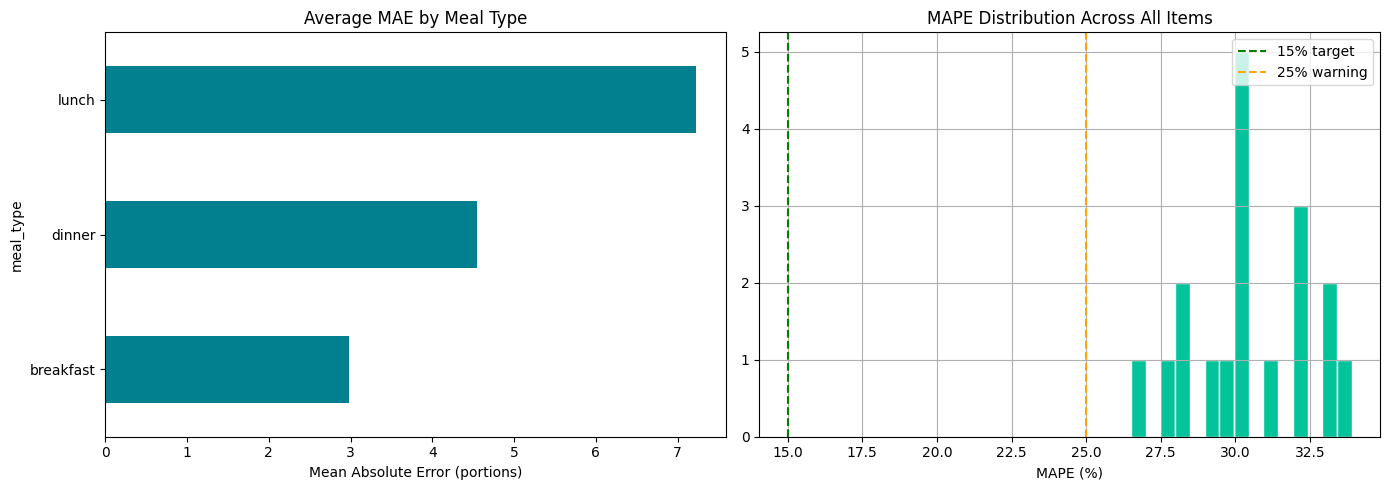

✅ Accuracy chart saved to models/training_accuracy.png


In [25]:
# ── Visualise accuracy across all items ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAE by meal type
results_df.groupby('meal_type')['mae'].mean().sort_values().plot(
    kind='barh', ax=axes[0], color='#028090')
axes[0].set_title('Average MAE by Meal Type')
axes[0].set_xlabel('Mean Absolute Error (portions)')

# MAPE distribution
results_df['mape'].hist(bins=15, ax=axes[1], color='#02C39A', edgecolor='white')
axes[1].axvline(x=15, color='green', linestyle='--', label='15% target')
axes[1].axvline(x=25, color='orange', linestyle='--', label='25% warning')
axes[1].set_title('MAPE Distribution Across All Items')
axes[1].set_xlabel('MAPE (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('models/training_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Accuracy chart saved to models/training_accuracy.png')

---
## STEP 11 — Save a Model Lookup Index

This JSON file tells your FastAPI which `.pkl` file to load for any given menu item + meal type.

In [5]:
#state recovery
import os, json
import pandas as pd

# Rebuild results_df from already-saved model files
model_files = [f for f in os.listdir('models') if f.endswith('.pkl')]

training_results = []
for filename in model_files:
    # Parse menu item and meal type from filename
    # e.g. prophet_Nasi_Lemak_breakfast.pkl
    name = filename.replace('prophet_', '').replace('.pkl', '')
    parts = name.split('_')
    
    # Last part is meal type, everything before is menu item
    meal_type = parts[-1]
    menu_item = ' '.join(parts[:-1]).replace('_', ' ')
    
    training_results.append({
        'menu_item':   menu_item,
        'meal_type':   meal_type,
        'model_path':  f'models/{filename}',
        'mae':         None,
        'mape':        None
    })

results_df = pd.DataFrame(training_results)
print(f'✅ results_df rebuilt from saved files: {len(results_df)} models found')
print(results_df[['menu_item','meal_type','model_path']].to_string(index=False))

✅ results_df rebuilt from saved files: 18 models found
          menu_item meal_type                                    model_path
  Burger   Sandwich     lunch    models/prophet_Burger___Sandwich_lunch.pkl
     Char Kuey Teow    dinner      models/prophet_Char_Kuey_Teow_dinner.pkl
       Economy Rice     lunch         models/prophet_Economy_Rice_lunch.pkl
         Fried Rice     lunch           models/prophet_Fried_Rice_lunch.pkl
      Kuih Assorted breakfast    models/prophet_Kuih_Assorted_breakfast.pkl
              Laksa     lunch                models/prophet_Laksa_lunch.pkl
         Mee Goreng     lunch           models/prophet_Mee_Goreng_lunch.pkl
   Mee Goreng Mamak breakfast models/prophet_Mee_Goreng_Mamak_breakfast.pkl
          Nasi Ayam     lunch            models/prophet_Nasi_Ayam_lunch.pkl
        Nasi Campur    dinner         models/prophet_Nasi_Campur_dinner.pkl
        Nasi Campur     lunch          models/prophet_Nasi_Campur_lunch.pkl
Nasi Goreng Kampung    dinner mod

In [3]:
import json

# Build lookup: { "Nasi Lemak_breakfast": "models/prophet_Nasi_Lemak_breakfast.pkl" }
model_index = {}
for _, row in results_df[results_df.model_path.notna()].iterrows():
    key = f"{row.menu_item}_{row.meal_type}"
    model_index[key] = row.model_path

with open('models/model_index.json', 'w') as f:
    json.dump(model_index, f, indent=2)

print(f'✅ Model index saved: {len(model_index)} models registered')
print('\nSample entries:')
for k, v in list(model_index.items())[:5]:
    print(f'  {k:40s} → {v}')

✅ Model index saved: 18 models registered

Sample entries:
  Burger   Sandwich_lunch                  → models/prophet_Burger___Sandwich_lunch.pkl
  Char Kuey Teow_dinner                    → models/prophet_Char_Kuey_Teow_dinner.pkl
  Economy Rice_lunch                       → models/prophet_Economy_Rice_lunch.pkl
  Fried Rice_lunch                         → models/prophet_Fried_Rice_lunch.pkl
  Kuih Assorted_breakfast                  → models/prophet_Kuih_Assorted_breakfast.pkl


---
## STEP 12 — Quick Prediction Test (All Ready!)

Load a saved model and run a prediction — this is exactly what FastAPI will do.

In [7]:
#state recovery
# ── Redefine predict_with_context function ────────────────────────────────────
import pandas as pd
import json

# Reload holidays_df too since it's needed inside the function
with open('models/model_index.json') as f:
    model_index = json.load(f)

def predict_with_context(model, input_date, weather, expected_pax,
                          is_long_weekend=0, is_wednesday_eve=0,
                          is_end_of_month=0, menu_item='', meal_type=''):
    weather_map = {'sunny': 0, 'cloudy': 1, 'rainy': 2}

    future = pd.DataFrame({
        'ds':               [pd.Timestamp(input_date)],
        'weather_code':     [weather_map.get(weather, 0)],
        'expected_pax':     [expected_pax],
        'is_long_weekend':  [is_long_weekend],
        'is_wednesday_eve': [is_wednesday_eve],
        'is_end_of_month':  [is_end_of_month],
    })

    forecast   = model.predict(future)
    predicted  = max(1, round(float(forecast['yhat'].iloc[0])))
    lower      = max(1, round(float(forecast['yhat_lower'].iloc[0])))
    upper      = max(1, round(float(forecast['yhat_upper'].iloc[0])))

    context_parts = []
    if weather == 'rainy':
        context_parts.append('rainy weather reduces foot traffic')
    elif weather == 'cloudy':
        context_parts.append('cloudy weather (slight reduction)')
    if is_long_weekend:
        context_parts.append('long weekend — many students leave campus')
    if is_wednesday_eve:
        context_parts.append('Wednesday evening — CCA activities reduce dinner crowd')
    if is_end_of_month:
        context_parts.append('end of month — student budget fatigue')

    context = '; '.join(context_parts) if context_parts else 'normal operating day'

    return {
        'menu_item':          menu_item or 'Unknown',
        'meal_type':          meal_type or 'Unknown',
        'date':               input_date,
        'predicted_portions': predicted,
        'confidence_range':   f'{lower}–{upper}',
        'expected_pax':       expected_pax,
        'weather':            weather,
        'context':            context,
        'instruction':        f'Prepare exactly {predicted} portions of {menu_item}.'
    }

print('✅ predict_with_context function ready!')
print(f'✅ model_index loaded — {len(model_index)} models available')

✅ predict_with_context function ready!
✅ model_index loaded — 18 models available


In [8]:
# ── Load a saved model and predict ────────────────────────────────────────────
import json, joblib

with open('models/model_index.json') as f:
    model_index = json.load(f)

# Pick a model to test
test_key = 'Nasi Campur_lunch'
loaded_model = joblib.load(model_index[test_key])

# Run prediction
result = predict_with_context(
    loaded_model,
    input_date   = '2025-01-15',
    weather      = 'rainy',
    expected_pax = 280,
    menu_item    = 'Nasi Campur',
    meal_type    = 'lunch'
)

print('=== PREDICTION RESULT ===')
for k, v in result.items():
    print(f'  {k:22s}: {v}')

=== PREDICTION RESULT ===
  menu_item             : Nasi Campur
  meal_type             : lunch
  date                  : 2025-01-15
  predicted_portions    : 86
  confidence_range      : 55–114
  expected_pax          : 280
  weather               : rainy
  context               : rainy weather reduces foot traffic
  instruction           : Prepare exactly 86 portions of Nasi Campur.


---
## ✅ YOU'RE DONE!

### What you now have in your `models/` folder:
```
models/
├── prophet_Nasi_Lemak_breakfast.pkl
├── prophet_Nasi_Campur_lunch.pkl
├── prophet_Nasi_Campur_dinner.pkl
├── ... (one .pkl per menu item)
├── model_index.json          ← FastAPI uses this to find the right model
├── training_results.csv      ← Accuracy scores for all models
└── training_accuracy.png     ← Visual accuracy chart
```

### Next step:
**Hand the `models/` folder to your backend teammate.** They will:
1. Copy it into the FastAPI project folder
2. Load models using `model_index.json`
3. Call `model.predict(input)` on each API request
4. Return `predicted_portions` + `context` as JSON to the dashboard

---
### 📌 Retraining reminder
When you get **real cafeteria data**, just:
1. Replace `kitcheniq_v2_full.csv` with your real data
2. Re-run this notebook from **Step 3** onwards
3. The new `.pkl` files will automatically replace the old ones